### Ⅰ データの取得・内容確認・加工

#### 1. pandasをインポート、バージョン確認

In [1]:
import pandas as pd
print(pd.__version__)

3.0.3


#### 2. SQLで作成したデータベースを追加

In [2]:
import sqlite3
con = sqlite3.connect("library_stats_2019.db")

In [3]:
sql = "SELECT * FROM v_library_over50k"
df = pd.read_sql(sql, con)
con.close()
df.head()

,設置者コード,県コード,県名,市区町村名,奉仕人口,蔵書冊数,受入冊数,うち購入,登録者数,貸出数,予約件数,決算額図書館費,決算額資料費,財政力指数
0,1100,1,北海道,札幌市,1952348,2673122,117922,59907,413805,6038900,1724967,845574,169733,0.73
1,1202,1,北海道,函館市,262519,720767,22967,16662,147284,1222233,105685,282313,36383,0.47
2,1203,1,北海道,小樽市,118948,316573,7920,5773,40944,297950,30019,50743,11700,0.44
3,1204,1,北海道,旭川市,340211,1267582,36613,26026,268252,2013823,249468,269208,50506,0.53
4,1205,1,北海道,室蘭市,85807,246901,29053,28080,27579,297955,22376,27275,15055,0.62


#### 3. データの確認１：各行列の確認

In [4]:
df.shape

(544, 14)

In [5]:
df.columns

Index(['設置者コード', '県コード', '県名', '市区町村名', '奉仕人口', '蔵書冊数', '受入冊数', 'うち購入', '登録者数',
       '貸出数', '予約件数', '決算額図書館費', '決算額資料費', '財政力指数'],
      dtype='str')

#### 4. データの確認２：各値（null値・0）の確認

In [6]:
(df[['奉仕人口', '蔵書冊数', '受入冊数', 'うち購入', '登録者数',
       '貸出数', '予約件数', '決算額図書館費', '決算額資料費', '財政力指数']] == 0).sum()

奉仕人口        0
蔵書冊数        0
受入冊数        0
うち購入        2
登録者数       16
貸出数         0
予約件数        0
決算額図書館費     0
決算額資料費      0
財政力指数       0
dtype: int64

「うち購入」及び「登録者数」に0があることが判明。

In [7]:
df[df['うち購入'] == 0]

,設置者コード,県コード,県名,市区町村名,奉仕人口,蔵書冊数,受入冊数,うち購入,登録者数,貸出数,予約件数,決算額図書館費,決算額資料費,財政力指数
126,11231,11,埼玉,桶川市,75234,218021,15630,0,58090,423112,53593,170063,14150,0.82
185,13117,13,東京,北区,348030,1363692,107777,0,148444,3851325,267337,1093495,196901,0.38


In [8]:
df[df['登録者数'] == 0]

,設置者コード,県コード,県名,市区町村名,奉仕人口,蔵書冊数,受入冊数,うち購入,登録者数,貸出数,予約件数,決算額図書館費,決算額資料費,財政力指数
28,4100,4,宮城,仙台市,1060545,2008765,73061,67519,0,4434917,206938,443776,153178,0.91
88,9213,9,栃木,那須塩原市,117902,415548,13444,11312,0,630942,55777,51126,23487,0.81
155,12220,12,千葉,流山市,185460,491332,14725,13401,0,1146669,209167,221235,35338,0.95
160,12227,12,千葉,浦安市,167938,1068955,38600,36777,0,1733663,485885,334528,96061,1.52
177,13109,13,東京,品川区,387622,1121450,89672,83801,0,3064437,1033282,1095904,176242,0.55
199,13208,13,東京,調布市,232473,1378521,50788,45181,0,2560006,656849,516763,159095,1.18
204,13213,13,東京,東村山市,151018,708184,25877,22973,0,1052635,234113,222636,40455,0.81
206,13215,13,東京,国立市,75723,383612,12039,11744,0,491096,82471,93949,25790,1.01
214,13225,13,東京,稲城市,89915,644199,16445,14408,0,1188531,235951,245683,39705,0.96
254,17206,17,石川,加賀市,67993,305454,10486,9625,0,310385,14034,43130,17946,0.58


In [9]:
# null値の確認
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 544 entries, 0 to 543
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   設置者コード   544 non-null    int64  
 1   県コード     544 non-null    int64  
 2   県名       544 non-null    str    
 3   市区町村名    544 non-null    str    
 4   奉仕人口     544 non-null    int64  
 5   蔵書冊数     544 non-null    int64  
 6   受入冊数     544 non-null    int64  
 7   うち購入     544 non-null    int64  
 8   登録者数     544 non-null    int64  
 9   貸出数      544 non-null    int64  
 10  予約件数     544 non-null    int64  
 11  決算額図書館費  544 non-null    int64  
 12  決算額資料費   544 non-null    int64  
 13  財政力指数    544 non-null    float64
dtypes: float64(1), int64(11), str(2)
memory usage: 59.6 KB


#### 5. データの置換：0をNaNに修正
各種統計量を算出するにあたり、値が0であるデータを除外するためにNaNに修正

In [10]:
import numpy as np
df['うち購入'] = df['うち購入'].replace(0, np.nan)
df['登録者数'] = df['登録者数'].replace(0, np.nan)

In [11]:
(df['うち購入'] == 0).sum()

np.int64(0)

In [12]:
(df['登録者数']== 0).sum()

np.int64(0)

In [13]:
df['うち購入'].isnull().sum()

np.int64(2)

In [14]:
df['登録者数'].isnull().sum()

np.int64(16)

#### 6. データの単位変換：単位を（千円）→（円）に変換

7において「奉仕人口」で除算するため、先に単位変換を行っておく。

In [15]:
df['決算額図書館費'] = df['決算額図書館費'] * 1000
df['決算額資料費'] = df['決算額資料費'] * 1000

#### 7. 各種統計量の追加

In [16]:
df["登録率"] = df["登録者数"] / df["奉仕人口"]
df["市民1人あたりの蔵書冊数"] = df["蔵書冊数"] / df["奉仕人口"]
df["市民1人あたりの貸出数"] = df["貸出数"] / df["奉仕人口"]
df["登録者1人あたりの貸出数"] = df["貸出数"] / df["登録者数"]
df["蔵書回転率"] = df["貸出数"] / df["蔵書冊数"]
df["市民1人あたりの図書館費"] = df["決算額図書館費"] / df["奉仕人口"]
df["市民1人あたりの資料費"] = df["決算額資料費"] / df["奉仕人口"]
df.head()

,設置者コード,県コード,県名,市区町村名,奉仕人口,蔵書冊数,受入冊数,うち購入,登録者数,貸出数,...,決算額図書館費,決算額資料費,財政力指数,登録率,市民1人あたりの蔵書冊数,市民1人あたりの貸出数,登録者1人あたりの貸出数,蔵書回転率,市民1人あたりの図書館費,市民1人あたりの資料費
0,1100,1,北海道,札幌市,1952348,2673122,117922,59907.0,413805.0,6038900,...,845574000,169733000,0.73,0.211952,1.369183,3.093147,14.593589,2.259119,433.106188,86.937882
1,1202,1,北海道,函館市,262519,720767,22967,16662.0,147284.0,1222233,...,282313000,36383000,0.47,0.561041,2.745580,4.655789,8.298478,1.695739,1075.400257,138.591873
2,1203,1,北海道,小樽市,118948,316573,7920,5773.0,40944.0,297950,...,50743000,11700000,0.44,0.344218,2.661440,2.504876,7.277013,0.941173,426.598177,98.362310
3,1204,1,北海道,旭川市,340211,1267582,36613,26026.0,268252.0,2013823,...,269208000,50506000,0.53,0.788487,3.725870,5.919335,7.507206,1.588712,791.297166,148.454929
4,1205,1,北海道,室蘭市,85807,246901,29053,28080.0,27579.0,297955,...,27275000,15055000,0.62,0.321407,2.877399,3.472386,10.803691,1.206779,317.864510,175.451886


#### 8. 各種統計量の確認

In [17]:
# ①各指標のうち、金額や件数等の整数で表される数値
df[['奉仕人口', '蔵書冊数', '受入冊数', 'うち購入', '登録者数',
       '貸出数', '予約件数', '決算額図書館費', '決算額資料費']].describe().astype(int)

,奉仕人口,蔵書冊数,受入冊数,うち購入,登録者数,貸出数,予約件数,決算額図書館費,決算額資料費
count,544,544,544,542,528,544,544,544,544
mean,197598,568697,21022,17734,81776,1074220,180826,202772981,39378233
std,301063,507900,22394,17510,91010,1397324,382193,279665055,40780371
min,50164,79251,2908,1800,7202,57774,829,9438000,2398000
25%,69026,263708,8525,7414,34479,345642,16852,62486250,14975000
50%,106646,410900,13621,11811,52516,596078,47874,107908500,24615500
75%,195433,678583,24839,21643,93320,1147023,146234,220734750,45322500
max,3737845,4237633,165533,126390,913064,11809552,3094719,2911789000,240623000


In [18]:
# ②各指標のうち、割合や比率等で表される数値
df[['財政力指数' ,'登録率', '市民1人あたりの蔵書冊数','市民1人あたりの貸出数','登録者1人あたりの貸出数','蔵書回転率','市民1人あたりの図書館費','市民1人あたりの資料費']].describe()

,財政力指数,登録率,市民1人あたりの蔵書冊数,市民1人あたりの貸出数,登録者1人あたりの貸出数,蔵書回転率,市民1人あたりの図書館費,市民1人あたりの資料費
count,544.000000,528.000000,544.000000,544.000000,528.000000,544.000000,544.000000,544.000000
mean,0.739577,0.504091,3.659118,5.685228,13.459546,1.655389,1111.715635,242.313329
std,0.218572,0.251414,1.463037,2.495934,7.813923,0.672313,764.305021,152.384741
min,0.230000,0.072160,0.977273,0.712432,3.141977,0.441175,117.694411,35.181394
25%,0.580000,0.322082,2.695145,3.982071,7.758951,1.158932,662.229730,155.345519
50%,0.740000,0.459479,3.421086,5.343766,11.159711,1.562277,938.186750,211.185335
75%,0.890000,0.634515,4.313465,6.831078,17.722046,2.004910,1310.668193,284.054560
max,1.520000,2.297067,11.102549,18.186870,52.785258,4.188907,8763.163755,1555.174721


### Ⅱ 分析①：「財政力指数」と「市民1人あたりの貸出数」の相関分析

#### 1. 相関係数の算出

In [19]:
df['財政力指数'].corr(df['市民1人あたりの貸出数'])

np.float64(0.32416714539206276)

#### 2. 散布図・回帰直線の描画

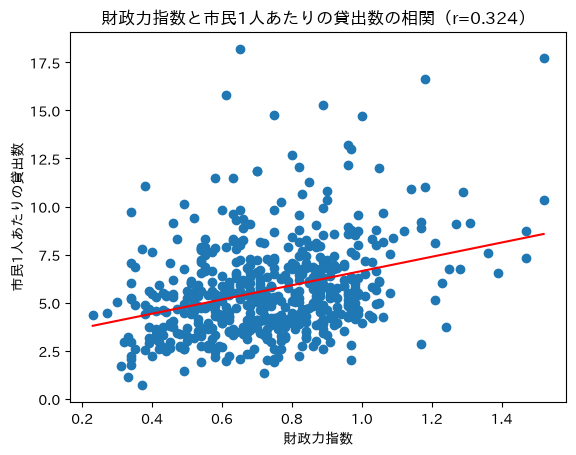

In [20]:
import matplotlib.pyplot as plt
import japanize_matplotlib
from scipy.stats import linregress

fig, ax = plt.subplots()

x = df['財政力指数']
y = df['市民1人あたりの貸出数']

slope, intercept, r_value, p_value, std_err = linregress(x, y)

ax.scatter(x, y)

x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, slope * x_line + intercept, color='red')

ax.set_title(f'財政力指数と市民1人あたりの貸出数の相関（r={r_value:.3f}）')
ax.set_xlabel('財政力指数')
ax.set_ylabel('市民1人あたりの貸出数')
plt.show()

In [21]:
print(f'回帰直線：y = {slope:.3f}x + {intercept:.3f} (x = {x.min()} ~ {x.max()} )')

回帰直線：y = 3.702x + 2.947 (x = 0.23 ~ 1.52 )


#### 3. 外れ値の確認

残差の値が大きい自治体を検証

In [22]:
df['市民1人あたりの予測貸出数'] = slope * df['財政力指数'] + intercept
df['残差'] = df['市民1人あたりの貸出数'] - df['市民1人あたりの予測貸出数']

df_resid = df[['設置者コード', '県名', '市区町村名','登録率', '財政力指数', '市民1人あたりの貸出数', '市民1人あたりの予測貸出数', '残差']].sort_values(by='残差', ascending = False)
df_resid.head(10)

,設置者コード,県名,市区町村名,登録率,財政力指数,市民1人あたりの貸出数,市民1人あたりの予測貸出数,残差
173,13105,東京,文京区,1.308575,0.65,18.186870,5.353636,12.833233
66,8216,茨城,笠間市,0.508477,0.61,15.788499,5.205566,10.582933
330,23223,愛知,大府市,0.623111,1.18,16.634089,7.315563,9.318526
194,13203,東京,武蔵野市,1.283716,1.52,17.750438,8.574157,9.176281
178,13110,東京,目黒区,0.431684,0.75,14.750493,5.723811,9.026682
169,13101,東京,千代田区,2.297067,0.89,15.262123,6.242056,9.020067
72,8224,茨城,守谷市,0.714279,1.00,14.722423,6.649248,8.073175
373,26211,京都,京田辺市,1.066812,0.80,12.685714,5.908898,6.776815
214,13225,東京,稲城市,NaN,0.96,13.218384,6.501178,6.717206
185,13117,東京,北区,0.426526,0.38,11.066072,4.354164,6.711908


※ 東京23区の自治体では「財政力指数」を独自の方法で算出しているため、外れ値の解釈には留意が必要

残差の値が大きい自治体について、各指標の順位を検証

In [23]:
df_rank = df[['設置者コード', '県名', '市区町村名', '残差']].copy()
df_rank['貸出数_順位'] = df['貸出数'].rank(ascending=False)
df_rank['貸出数/奉仕人口_順位'] = df['市民1人あたりの貸出数'].rank(ascending=False)
df_rank['財政力指数_順位'] = df['財政力指数'].rank(ascending=False)
df_rank['奉仕人口_順位'] = df['奉仕人口'].rank(ascending=False)
df_rank['蔵書冊数_順位'] = df['蔵書冊数'].rank(ascending=False)
df_rank['登録者数_順位'] = df['登録者数'].rank(ascending=False)
df_rank['登録率_順位'] = df['登録率'].rank(ascending=False)
df_rank['資料費/奉仕人口_順位'] = df['市民1人あたりの資料費'].rank(ascending=False)

df_rank.sort_values(by='残差', ascending=False).head(10)

,設置者コード,県名,市区町村名,残差,貸出数_順位,貸出数/奉仕人口_順位,財政力指数_順位,奉仕人口_順位,蔵書冊数_順位,登録者数_順位,登録率_順位,資料費/奉仕人口_順位
173,13105,東京,文京区,12.833233,25.0,1.0,351.0,125.0,55.0,22.0,3.0,25.0
66,8216,茨城,笠間市,10.582933,128.0,4.0,387.5,374.0,192.0,354.0,218.0,37.0
330,23223,愛知,大府市,9.318526,98.0,3.0,16.5,309.0,297.0,234.0,142.0,38.0
194,13203,東京,武蔵野市,9.176281,51.0,2.0,1.5,192.0,82.0,48.0,4.0,10.0
178,13110,東京,目黒区,9.026682,23.0,6.0,261.5,93.0,51.0,97.0,287.0,93.0
169,13101,東京,千代田区,9.020067,172.0,5.0,130.5,459.0,191.0,76.0,1.0,1.0
72,8224,茨城,守谷市,8.073175,161.0,7.0,47.5,421.0,253.0,290.0,99.0,19.0
373,26211,京都,京田辺市,6.776815,187.0,10.0,223.5,408.0,313.0,175.0,15.0,79.0
214,13225,東京,稲城市,6.717206,132.0,8.0,82.5,314.0,145.0,NaN,NaN,39.0
185,13117,東京,北区,6.711908,27.0,19.0,521.5,69.0,37.0,67.0,295.0,16.0


市民1人あたりの資料費の順位（資料費/奉仕人口_順位）について、比較的高い傾向があることを観測

続いて、残差のマイナスの値が大きい自治体を検証

In [24]:
df_resid.tail(10)

,設置者コード,県名,市区町村名,登録率,財政力指数,市民1人あたりの貸出数,市民1人あたりの予測貸出数,残差
64,8211,茨城,常総市,0.289681,0.73,2.021550,5.649776,-3.628226
483,40130,福岡,福岡市,0.315772,0.89,2.603883,6.242056,-3.638172
60,8204,茨城,古河市,0.486683,0.75,2.075844,5.723811,-3.647967
218,14100,神奈川,横浜市,0.244276,0.97,2.801298,6.538196,-3.736897
433,30201,和歌山,和歌山市,0.425806,0.82,2.244239,5.982933,-3.738694
21,3201,岩手,盛岡市,0.480263,0.75,1.923689,5.723811,-3.800122
120,11224,埼玉,戸田市,0.163402,1.24,3.726239,7.537668,-3.811428
385,27209,大阪,守口市,0.431396,0.72,1.355436,5.612759,-4.257323
345,24202,三重,四日市市,0.176194,1.17,2.865497,7.278545,-4.413048
225,14206,神奈川,小田原市,0.151863,0.97,2.023381,6.538196,-4.514814


残差のマイナスの値が大きい自治体についても、各指標の順位を検証

In [25]:
df_rank.sort_values(by='残差', ascending=True).head(10)

,設置者コード,県名,市区町村名,残差,貸出数_順位,貸出数/奉仕人口_順位,財政力指数_順位,奉仕人口_順位,蔵書冊数_順位,登録者数_順位,登録率_順位,資料費/奉仕人口_順位
225,14206,神奈川,小田原市,-4.514814,375.0,534.0,70.5,139.0,252.0,426.0,521.0,527.0
345,24202,三重,四日市市,-4.413048,182.0,497.0,19.0,82.0,217.0,245.0,512.0,501.0
385,27209,大阪,守口市,-4.257323,514.0,542.0,290.0,195.0,520.0,210.0,288.0,502.0
120,11224,埼玉,戸田市,-3.811428,305.0,433.0,12.0,202.0,293.0,471.0,516.0,244.0
21,3201,岩手,盛岡市,-3.800122,288.0,537.0,261.5,86.0,143.0,79.0,244.0,537.0
433,30201,和歌山,和歌山市,-3.738694,202.0,525.0,203.5,64.0,213.0,62.0,296.0,466.0
218,14100,神奈川,横浜市,-3.736897,3.0,498.0,70.5,1.0,2.0,1.0,462.0,541.0
60,8204,茨城,古河市,-3.647967,445.0,532.0,261.5,193.0,390.0,184.0,239.0,503.0
483,40130,福岡,福岡市,-3.638172,24.0,513.0,130.5,6.0,14.0,3.0,404.0,534.0
64,8211,茨城,常総市,-3.628226,536.0,535.0,281.5,433.0,532.0,498.0,425.0,344.0


上記の結果からも、市民1人あたりの資料費の順位（資料費/奉仕人口_順位）が全体的に低い傾向があることを観測（その他、登録率の順位も全体的に低い）

仮説①が実証できなかったため、各指標同士の相関係数を確認

In [26]:
df_corr = df[['財政力指数' ,'登録率', '市民1人あたりの蔵書冊数','市民1人あたりの貸出数','登録者1人あたりの貸出数','蔵書回転率','市民1人あたりの図書館費','市民1人あたりの資料費']]
df_corr.corr()

,財政力指数,登録率,市民1人あたりの蔵書冊数,市民1人あたりの貸出数,登録者1人あたりの貸出数,蔵書回転率,市民1人あたりの図書館費,市民1人あたりの資料費
財政力指数,1.000000,0.156567,0.002549,0.324167,0.145884,0.331598,0.111063,0.065058
登録率,0.156567,1.000000,0.358485,0.348024,-0.569474,-0.012922,0.207098,0.243971
市民1人あたりの蔵書冊数,0.002549,0.358485,1.000000,0.502751,0.039071,-0.378929,0.349291,0.521562
市民1人あたりの貸出数,0.324167,0.348024,0.502751,1.000000,0.418451,0.528892,0.540135,0.485590
登録者1人あたりの貸出数,0.145884,-0.569474,0.039071,0.418451,1.000000,0.426431,0.238110,0.140860
蔵書回転率,0.331598,-0.012922,-0.378929,0.528892,0.426431,1.000000,0.200973,-0.007106
市民1人あたりの図書館費,0.111063,0.207098,0.349291,0.540135,0.238110,0.200973,1.000000,0.415288
市民1人あたりの資料費,0.065058,0.243971,0.521562,0.485590,0.140860,-0.007106,0.415288,1.000000


貸出数と相関の高い指標は複数あるが、上記結果及び「施策に反映可能」という観点から、今回は資料費に注目する(詳細はZenn記事Ⅱ(2)を参照)

### Ⅲ 分析②：「市民1人あたりの資料費」と「市民1人あたりの貸出数」の相関

#### 1. 相関係数の算出

In [27]:
df['市民1人あたりの資料費'].corr(df['市民1人あたりの貸出数'])

np.float64(0.48558986568810686)

#### 2. 散布図・回帰直線の描画

Text(0, 0.5, '市民1人あたりの貸出数')

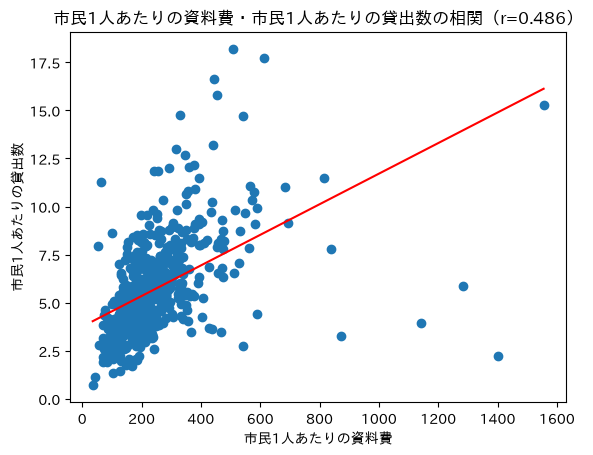

In [28]:
fig, ax = plt.subplots()

x = df['市民1人あたりの資料費']
y = df['市民1人あたりの貸出数']

ax.scatter(x, y)

slope, intercept, r_value, p_value, std_err = linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, slope * x_line + intercept, color='red')

ax.set_title(f'市民1人あたりの資料費・市民1人あたりの貸出数の相関（r={r_value:.3f}）')
ax.set_xlabel('市民1人あたりの資料費')
ax.set_ylabel('市民1人あたりの貸出数')


In [29]:
print(f'回帰直線：y = {slope:.3f}x + {intercept:.3f} (x = {x.min()} ~ {x.max()} )')

回帰直線：y = 0.008x + 3.758 (x = 35.18139443115397 ~ 1555.1747213109402 )


#### 3. 外れ値の確認

2の散布図における外れ値のうち、まずは右下側にある外れ値を検証
「市民1人あたりの資料費」が800円以上かつ「市民1人あたりの貸出数」が7.5未満である4点が大きく外れているため、内訳を検証

In [30]:
df[(df['市民1人あたりの資料費'] > 800) & (df['市民1人あたりの貸出数'] < 7.5)]

,設置者コード,県コード,県名,市区町村名,奉仕人口,蔵書冊数,受入冊数,うち購入,登録者数,貸出数,...,財政力指数,登録率,市民1人あたりの蔵書冊数,市民1人あたりの貸出数,登録者1人あたりの貸出数,蔵書回転率,市民1人あたりの図書館費,市民1人あたりの資料費,市民1人あたりの予測貸出数,残差
31,4205,4,宮城,気仙沼市,64947,325520,7833,5100.0,25797.0,256357,...,0.45,0.397201,5.012087,3.947172,9.937473,0.787531,701.402682,1141.099666,4.613286,-0.666114
59,8203,8,茨城,土浦市,143024,427849,18184,17239.0,40665.0,836074,...,0.87,0.284323,2.991449,5.845690,20.560039,1.954133,1217.557892,1282.176418,6.168021,-0.322331
158,12224,12,千葉,鎌ケ谷市,109919,303624,8834,7849.0,29364.0,359386,...,0.78,0.267142,2.762252,3.269553,12.239000,1.183655,947.261165,871.196063,5.834863,-2.565310
543,47214,47,沖縄,宮古島市,54442,153664,39988,39544.0,22949.0,120518,...,0.34,0.421531,2.822527,2.213695,5.251558,0.784296,2217.626097,1400.058778,4.206094,-1.992399


上記4自治体について、各指標の順位を確認

In [31]:
df_rank[(df['設置者コード']== 4205) | (df['設置者コード']== 8203) | (df['設置者コード']== 12224) | (df['設置者コード']== 47214)]

,設置者コード,県名,市区町村名,残差,貸出数_順位,貸出数/奉仕人口_順位,財政力指数_順位,奉仕人口_順位,蔵書冊数_順位,登録者数_順位,登録率_順位,資料費/奉仕人口_順位
31,4205,宮城,気仙沼市,-0.666114,481.0,415.0,490.0,431.0,331.0,446.0,322.0,4.0
59,8203,茨城,土浦市,-0.322331,201.0,219.0,155.0,196.0,255.0,343.0,431.0,3.0
158,12224,千葉,鎌ケ谷市,-2.565310,397.0,471.0,235.5,269.0,367.0,424.0,449.0,5.0
543,47214,沖縄,宮古島市,-1.992399,538.0,528.0,533.0,506.0,525.0,469.0,301.0,2.0


2の散布図のうち、左上側の外れ値上位はⅡ3で示した自治体と推定されるが、念のため確認
（特に外れ値の大きい「市民1人あたりの資料費」が800円未満かつ「市民1人あたりの貸出数」が14.0冊以上を確認）

In [32]:
df[(df['市民1人あたりの資料費'] < 800) & (df['市民1人あたりの貸出数'] > 14.0)]

,設置者コード,県コード,県名,市区町村名,奉仕人口,蔵書冊数,受入冊数,うち購入,登録者数,貸出数,...,財政力指数,登録率,市民1人あたりの蔵書冊数,市民1人あたりの貸出数,登録者1人あたりの貸出数,蔵書回転率,市民1人あたりの図書館費,市民1人あたりの資料費,市民1人あたりの予測貸出数,残差
66,8216,8,茨城,笠間市,76969,543813,18604,15702.0,39137.0,1215225,...,0.61,0.508477,7.065351,15.788499,31.050540,2.234638,2238.329717,452.519846,5.205566,10.582933
72,8224,8,茨城,守谷市,66922,429284,15832,15029.0,47801.0,985254,...,1.00,0.714279,6.414692,14.722423,20.611577,2.295110,2751.964974,542.855862,6.649248,8.073175
173,13105,13,東京,文京区,217419,1153443,47809,44436.0,284509.0,3954171,...,0.65,1.308575,5.305162,18.186870,13.898228,3.428146,5724.490500,508.368634,5.353636,12.833233
178,13110,13,東京,目黒区,276786,1195070,70156,61971.0,119484.0,4082730,...,0.75,0.431684,4.317668,14.750493,34.169680,3.416310,2324.337214,330.374369,5.723811,9.026682
194,13203,13,東京,武蔵野市,144902,921590,45930,34327.0,186013.0,2572074,...,1.52,1.283716,6.360092,17.750438,13.827388,2.790909,2965.707858,613.476695,8.574157,9.176281
330,23223,23,愛知,大府市,91913,373478,19381,17846.0,57272.0,1528889,...,1.18,0.623111,4.063386,16.634089,26.695226,4.093652,1772.893932,445.551772,7.315563,9.318526


全てⅡ3で示した自治体であったため、改めての分析は割愛

### Ⅳ 分析③：「奉仕人口」と「市民1人あたりの貸出数」の関係性

#### 1. 相関係数の算出

In [33]:
df['奉仕人口'].corr(df['市民1人あたりの貸出数'])

np.float64(-0.06555708722754415)

相関関係はほぼないが、散布図から関係性があるかどうかを探索する

#### 2. 散布図の描画

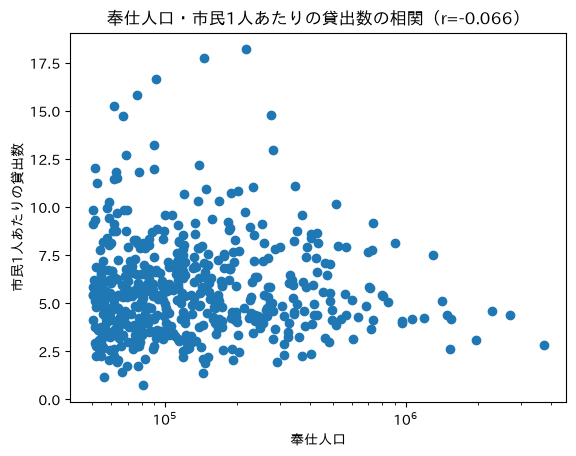

In [34]:
fig, ax = plt.subplots()

x = df['奉仕人口']
y = df['市民1人あたりの貸出数']
slope, intercept, r_value, p_value, std_err = linregress(x, y)
ax.scatter(x, y)
ax.set_title(f'奉仕人口・市民1人あたりの貸出数の相関（r={r_value:.3f}）')
ax.set_xlabel('奉仕人口')
ax.set_ylabel('市民1人あたりの貸出数')
ax.set_xscale('log') # 本図では奉仕人口を対数で表示

plt.show()

奉仕人口が比較的少ない自治体では「市民1人あたりの貸出数」のばらつきが大きく、奉仕人口が増えるに従ってばらつきが減っていく、という特徴を把握

#### 3. 奉仕人口を３分割

ばらつきの程度の差異を数値化するため、散布図の結果から自治体の人口規模を「(5万人以上)30万人未満」「30万人以上50万人未満」「50万人以上」を基準に分割

In [35]:
df_small = df[df['奉仕人口'] < 300000]
df_middle = df[(df['奉仕人口'] >= 300000) & (df['奉仕人口'] < 500000)]
df_large = df[df['奉仕人口'] >= 500000]

# 各群における要素数の確認
print(len(df_small), len(df_middle), len(df_large))

459 50 35


#### 4. 散布図の描画

分割の目的は5の検証だが、参考に散布図を確認

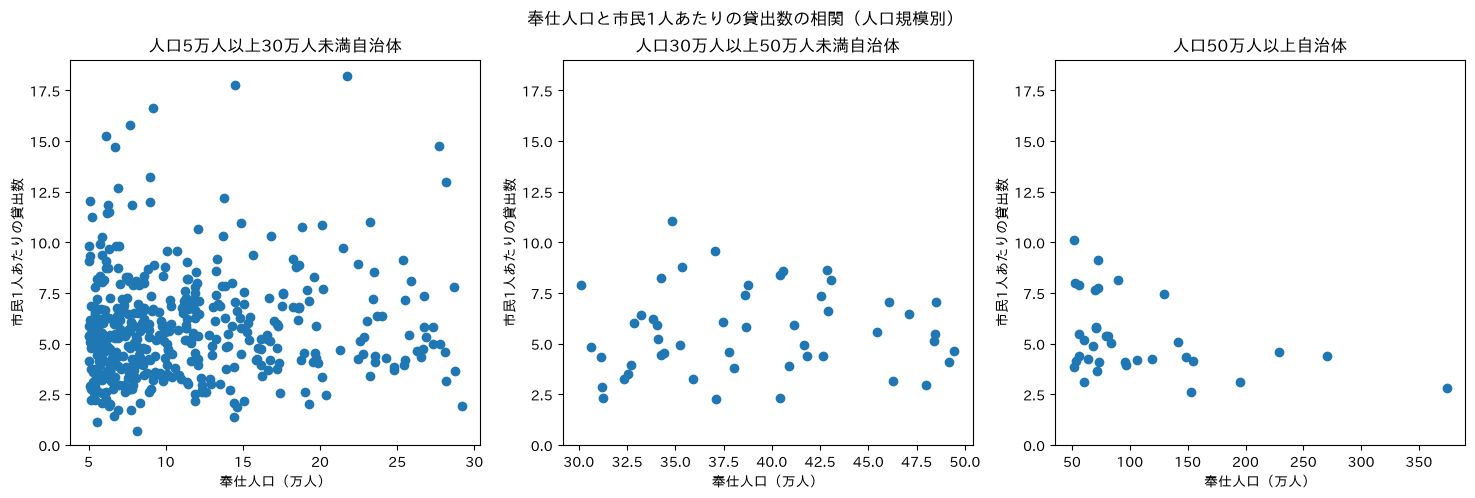

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
groups = [
    (df_small, '人口5万人以上30万人未満'),
    (df_middle, '人口30万人以上50万人未満'),
    (df_large, '人口50万人以上'),
]

for ax, (data, label) in zip(axes, groups):
    x = data['奉仕人口'] / 10000 # 単位を「万人」にして表示
    y = data['市民1人あたりの貸出数']
    
    ax.scatter(x, y)
    ax.set_title(f'{label}自治体')
    ax.set_xlabel('奉仕人口（万人）')
    ax.set_ylabel('市民1人あたりの貸出数')
    ax.set_ylim(0, 19.0)

fig.suptitle('奉仕人口と市民1人あたりの貸出数の相関（人口規模別）')
plt.show()

上図においては、それぞれでx軸の間隔が異なる点に留意

#### 5. 3群の平均値・標準偏差・変動係数の確認

ばらつきの程度の差異を数値化し、3群を比較する

In [37]:
# ① df_small の平均値・標準偏差・変動係数を算出
df_small_mean = df_small['市民1人あたりの貸出数'].mean()
df_small_std = df_small['市民1人あたりの貸出数'].std()
df_small_cv = df_small_std / df_small_mean

# ② df_middle の平均値・標準偏差・変動係数を算出
df_middle_mean = df_middle['市民1人あたりの貸出数'].mean()
df_middle_std = df_middle['市民1人あたりの貸出数'].std()
df_middle_cv  = df_middle_std / df_middle_mean

# ③ df_large の平均値・標準偏差・変動係数を算出
df_large_mean = df_large['市民1人あたりの貸出数'].mean()
df_large_std = df_large['市民1人あたりの貸出数'].std()
df_large_cv = df_large_std / df_large_mean

In [38]:
df_stat = pd.DataFrame([[df_small_mean, df_small_std, df_small_cv],
             [df_middle_mean, df_middle_std, df_middle_cv],
             [df_large_mean, df_large_std, df_large_cv]],
             index=['人口5万人以上30万人未満','人口30万人以上50万人未満','人口50万人以上'],
             columns=['平均値', '標準偏差', '変動係数'])
df_stat

,平均値,標準偏差,変動係数
人口5万人以上30万人未満,5.725910,2.579004,0.450409
人口30万人以上50万人未満,5.609608,2.070230,0.369051
人口50万人以上,5.259742,1.871240,0.355766


特に奉仕人口が30万人を境に、変動係数が大きく減少していることを確認。30万人以上から50万人以上においても、ゆるやかに減少している

#### 6. 箱ひげ図の描画

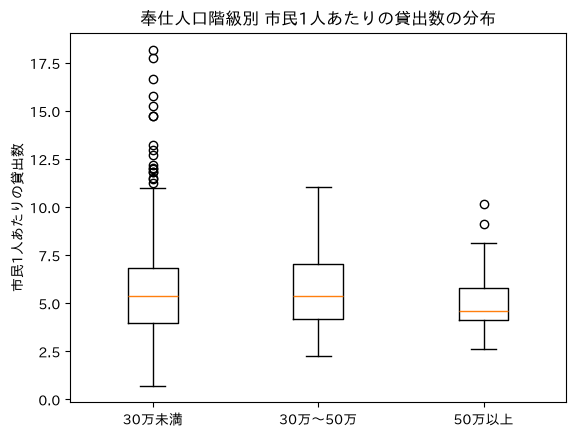

In [39]:
fig, ax = plt.subplots()

bp1 = df_small['市民1人あたりの貸出数']
bp2 = df_middle['市民1人あたりの貸出数']
bp3 = df_large['市民1人あたりの貸出数']

ax.boxplot((bp1, bp2, bp3), tick_labels=['30万未満', '30万〜50万', '50万以上'])

ax.set_title('奉仕人口階級別 市民1人あたりの貸出数の分布')
ax.set_ylabel('市民1人あたりの貸出数')
plt.show()